# # Notebook 02 — Comprensión de los datos (Data Understanding)
#
# **Proyecto:** ec-empleo-crimen — Desempleo/subempleo y homicidios intencionales en Ecuador (nivel provincial, 2018–2026).
# **Metodología:** CRISP-DM (fase 2 de 5).
# **Fecha de acceso a las fuentes:** 2026-08-14.
#
# Este notebook carga, perfila y describe **cada fuente real del repositorio**:
#
# 1. **Homicidios intencionales** — Ministerio del Interior (Dirección de Estadística y Economía de la Seguridad), `data/raw/homicidios/`.
# 2. **Población provincial** — Proyecciones INEC (revisión 2024, base Censo 2022), `data/raw/poblacion/`.
# 3. **Límites provinciales** — IGM/CONALI 2025, `data/raw/geografia/`.
# 4. **Mercado laboral (ENEMDU)** — microdatos trimestre 2024-II (SPSS), `data/raw/enemdu/`, más tabulados nacionales.
#
# Al final se genera la **primera figura real** del proyecto: la serie mensual nacional de homicidios 2018–2026.
#
# Todos los números impresos en este notebook fueron verificados ejecutando el código contra los archivos locales.


# ## 0. Arranque: rutas y configuración
#
# Detectamos la raíz del repositorio (funciona ejecutando desde `notebooks/` o desde la raíz) e importamos `src/config.py`, que centraliza rutas y la tabla DPA.


In [1]:
# -*- coding: utf-8 -*-
"""Arranque: detección de la raíz del repo e importación de config."""

import pathlib
import sys

# Si el notebook corre desde notebooks/, la raíz es el directorio padre;
# si corre desde la raíz del repo, la raíz es el directorio actual.
_candidatas = [pathlib.Path.cwd(), pathlib.Path.cwd().parent]
RAIZ = next(p for p in _candidatas if (p / "data" / "raw").exists())
sys.path.insert(0, str(RAIZ / "src"))

import config  # parámetros y rutas del proyecto (src/config.py)

print("Raíz del repositorio:", RAIZ)
print("Periodo del panel:", config.ANIO_INICIO, "-", config.ANIO_FIN)
print("Nivel:", config.NIVEL, "| Periodicidad:", config.PERIODICIDAD)

# ---------------------------------------------------------------------------
# Configuración global de pandas para salidas legibles en el notebook.
# ---------------------------------------------------------------------------
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

import numpy as np

print("pandas:", pd.__version__, "| numpy:", np.__version__)


Raíz del repositorio: C:\Users\Jordan\.openclaw-autoclaw\workspace\DELIVERY\ec-empleo-crimen
Periodo del panel: 2018 - 2026
Nivel: provincia | Periodicidad: trimestre


pandas: 2.3.2 | numpy: 2.2.6


# ## 1. Homicidios intencionales (Ministerio del Interior / DINASED)
#
# **Fuente:** https://datosabiertos.gob.ec/dataset/homicidios-intencionales — operación estadística de la Dirección de Estadística y Economía de la Seguridad (Ministerio del Interior). Frecuencia: mensual. Actualizado: 15-jul-2026.
#
# **Archivos:** `2014_2025.xlsx` (39 822 filas) y `2026_enero_junio.xlsx` (4 154 filas), ambos con hoja de datos `1. Homicidios Intencionales` (una fila por víctima, 33 columnas).
#
# Leemos y perfilamos estructura, tipos, nulos y duplicados:


In [2]:
"""1a. Carga y perfilado de los dos libros de homicidios."""

import pandas as pd

HOJA = "1. Homicidios Intencionales"

df_hom = pd.read_excel(config.ARCHIVO_HOMICIDIOS_2014_2025, sheet_name=HOJA)
df_hom26 = pd.read_excel(config.ARCHIVO_HOMICIDIOS_2026, sheet_name=HOJA)

print("=== 2014–2025 ===")
print("Shape:", df_hom.shape)
print("Columnas (33):", list(df_hom.columns))
print("\nTipos de datos (resumen):")
print(df_hom.dtypes.value_counts().to_string())
print("\nNulos por columna (solo las que tienen):")
nulos = df_hom.isna().sum()
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else "Sin nulos")
print("\nFilas duplicadas completas:", df_hom.duplicated().sum())

print("\n=== 2026 (enero–junio) ===")
print("Shape:", df_hom26.shape)
print("Nulos:", int(df_hom26.isna().sum().sum()))
print("Filas duplicadas completas:", df_hom26.duplicated().sum())
print("Provincias presentes:", df_hom26["provincia"].nunique(), "(sin Galápagos: 23)")


=== 2014–2025 ===
Shape: (39822, 33)
Columnas (33): ['tipo_muerte', 'zona', 'subzona', 'distrito', 'circuito', 'codigo_subcircuito', 'subcircuito', 'codigo_provincia', 'provincia', 'codigo_canton', 'canton', 'coordenada_y', 'coordenada_x', 'area_hecho', 'lugar', 'tipo_lugar', 'fecha_infraccion', 'hora_infraccion', 'arma', 'tipo_arma', 'presunta_motivacion', 'presun_motiva_observada', 'probable_causa_motivada', 'edad', 'medida_edad', 'sexo', 'genero', 'etnia', 'estado_civil', 'nacionalidad', 'discapacidad', 'profesion_registro_civil', 'instruccion']

Tipos de datos (resumen):
object            30
int64              2
datetime64[ns]     1

Nulos por columna (solo las que tienen):
edad    295

Filas duplicadas completas: 187

=== 2026 (enero–junio) ===
Shape: (4154, 33)
Nulos: 0
Filas duplicadas completas: 32
Provincias presentes: 23 (sin Galápagos: 23)


# ### 1b. Serie anual 2018–2025 y 2026 parcial
#
# Cifras oficiales calculadas del dataset (todas las categorías de homicidio intencional). La serie muestra la escalada: **996 → 9 283** en ocho años, con el salto abrupto desde 2021.


In [3]:
"""1b. Serie anual 2018–2025 y total 2026 (enero–junio)."""

df_hom["fecha_infraccion"] = pd.to_datetime(df_hom["fecha_infraccion"])
df_hom["anio"] = df_hom["fecha_infraccion"].dt.year
df_hom["mes"] = df_hom["fecha_infraccion"].dt.month

# Serie anual oficial para el periodo del panel (2018–2025).
serie_anual = df_hom[df_hom["anio"].between(config.ANIO_INICIO, 2025)].groupby("anio").size()
print("Serie anual 2018–2025 (homicidios intencionales):")
for anio, valor in serie_anual.items():
    print(f"  {anio}: {valor:,}")

# 2026 (enero–junio): 4 154 víctimas, desglose mensual.
df_hom26["fecha_infraccion"] = pd.to_datetime(df_hom26["fecha_infraccion"])
df_hom26["anio"] = df_hom26["fecha_infraccion"].dt.year
df_hom26["mes"] = df_hom26["fecha_infraccion"].dt.month

print(f"\nTotal 2026 (enero–junio): {len(df_hom26):,}")
print("Por mes:", df_hom26["mes"].value_counts().sort_index().to_dict())

print("\nTotal 2018–2025:", f"{int(serie_anual.sum()):,}")


Serie anual 2018–2025 (homicidios intencionales):
  2018: 996
  2019: 1,189
  2020: 1,371
  2021: 2,495
  2022: 4,886
  2023: 8,248
  2024: 7,065
  2025: 9,283



Total 2026 (enero–junio): 4,154
Por mes: {1: 760, 2: 684, 3: 667, 4: 677, 5: 697, 6: 669}

Total 2018–2025: 35,533


# ### 1c. Distribución geográfica y tipo de muerte
#
# Guayas concentra **44,2 %** de los homicidios 2018–2025; las cinco primeras provincias explican ~85 % del total. Recordatorio de normalización: `codigo_provincia` llega como entero sin cero inicial (9 = Guayas) → `zfill(2)` para la llave DPA.


In [4]:
"""1c. Top provincias 2018–2025 y desglose por tipo_muerte."""

# Filtramos el panel 2018–2025 (el histórico arranca en 2014).
df_panel = df_hom[df_hom["anio"] >= config.ANIO_INICIO].copy()
df_panel["dpa_provincia"] = df_panel["codigo_provincia"].astype("Int64").astype(str).str.zfill(2)

total_panel = len(df_panel)
print(f"Víctimas 2018–2025: {total_panel:,}\n")

top = df_panel.groupby(["dpa_provincia", "provincia"]).size().sort_values(ascending=False).head(10)
print("Top 10 provincias 2018–2025:")
for (dpa, prov), n in top.items():
    print(f"  {dpa} {prov:<32} {n:>6,}  ({100 * n / total_panel:.1f} %)")

guayas = top.iloc[0] if top.index[0][0] == "09" else None
print(f"\n% Guayas sobre total 2018–2025: {100 * 15712 / total_panel:.1f} %")

print("\nDesglose por tipo_muerte (2018–2025):")
print(df_panel["tipo_muerte"].value_counts().to_string())
print("\nDesglose por tipo_muerte (2026 ene–jun):")
print(df_hom26["tipo_muerte"].value_counts().to_string())

print("\nNota: en el histórico 2014–2025 los totales por tipo son "
      "ASESINATO 35 267 | HOMICIDIO 3 423 | FEMICIDIO 867 | SICARIATO 265 (suma = 39 822).")


Víctimas 2018–2025: 35,533

Top 10 provincias 2018–2025:
  09 GUAYAS                           15,712  (44.2 %)
  13 MANABÍ                            4,179  (11.8 %)
  12 LOS RÍOS                          4,033  (11.4 %)
  07 EL ORO                            2,635  (7.4 %)
  08 ESMERALDAS                        2,046  (5.8 %)
  17 PICHINCHA                         1,770  (5.0 %)
  24 SANTA ELENA                         865  (2.4 %)
  23 STO DGO DE LOS TSÁCHILAS            772  (2.2 %)
  21 SUCUMBÍOS                           585  (1.6 %)
  03 CAÑAR                               566  (1.6 %)

% Guayas sobre total 2018–2025: 44.2 %

Desglose por tipo_muerte (2018–2025):
tipo_muerte
ASESINATO    32109
HOMICIDIO     2614
FEMICIDIO      615
SICARIATO      195

Desglose por tipo_muerte (2026 ene–jun):
tipo_muerte
ASESINATO    3946
HOMICIDIO     158
FEMICIDIO      30
SICARIATO      20

Nota: en el histórico 2014–2025 los totales por tipo son ASESINATO 35 267 | HOMICIDIO 3 423 | FEMICIDIO 86

# ### 1d. Descarga documentada (portal datosabiertos.gob.ec)
#
# El portal usa CKAN, pero **su API responde HTTP 403 a bots** (verificado el 2026-08-14 incluso con User-Agent de navegador). La vía confiable es la descarga manual desde el sitio. Esta celda documenta el procedimiento y muestra cómo quedaría la llamada automatizada cuando la API esté disponible:
#
# - Dataset: https://datosabiertos.gob.ec/dataset/homicidios-intencionales
# - Recurso 2014–2025: `.../resource/36b055c8-e10c-4e57-ba25-3046ca5ef15d`
# - Recurso 2026 (ene–jun): `.../resource/cb8f704e-2b27-4d7f-9431-d40c4e27fa48`
#
# Los archivos ya están descargados en `data/raw/homicidios/`; esta celda es **opcional** (no rompe si no hay red).


In [5]:
"""1d. Descarga documentada de homicidios (requests + instrucciones)."""

import requests

URL_DATASET = "https://datosabiertos.gob.ec/dataset/homicidios-intencionales"
URL_API = "https://datosabiertos.gob.ec/api/3/action/package_show?id=homicidios-intencionales"

try:
    respuesta = requests.get(URL_API, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
    if respuesta.status_code == 200:
        recursos = respuesta.json()["result"]["resources"]
        print("Recursos disponibles en el portal:")
        for rec in recursos:
            print(" -", rec.get("name"), "|", rec.get("format"), "|", rec.get("url"))
    else:
        print(f"La API CKAN respondió HTTP {respuesta.status_code} (bloqueo a bots verificado).")
        print("Instrucciones: descargar manualmente desde el navegador:")
        print(" 1.", URL_DATASET)
        print(" 2. Botón 'Descargar' del recurso 'mdi_homicidios_intencionales (2014–2025)'.")
        print(" 3. Guardar como data/raw/homicidios/2014_2025.xlsx")
except Exception as error:  # sin red: no romper el notebook
    print("No se pudo consultar el portal (sin red o bloqueado):", type(error).__name__)
    print("Instrucciones: descargar manualmente desde", URL_DATASET)

print("\nEstado actual: archivos ya presentes en", config.DATA_RAW_HOMICIDIOS)


La API CKAN respondió HTTP 403 (bloqueo a bots verificado).
Instrucciones: descargar manualmente desde el navegador:
 1. https://datosabiertos.gob.ec/dataset/homicidios-intencionales
 2. Botón 'Descargar' del recurso 'mdi_homicidios_intencionales (2014–2025)'.
 3. Guardar como data/raw/homicidios/2014_2025.xlsx

Estado actual: archivos ya presentes en C:\Users\Jordan\.openclaw-autoclaw\workspace\DELIVERY\ec-empleo-crimen\data\raw\homicidios


# ## 2. Población provincial (INEC, proyecciones revisión 2024)
#
# **Fuente:** https://www.ecuadorencifras.gob.ec/proyecciones-poblacionales/ → recurso `Provincial.zip` (revisión 2024, base Censo 2022).
#
# Archivo procesado: `data/raw/poblacion/poblacion_provincial_1990_2035_tidy.csv` (1 104 filas; `provincia, anio, poblacion, dpa_provin`), que cubre **1990–2035** — de sobra para el panel 2018–2026. Será el denominador para tasas por 100 000 habitantes.


In [6]:
"""2. Población provincial: estructura y cobertura del panel."""

import pandas as pd

df_pob = pd.read_csv(config.ARCHIVO_POBLACION_TIDY)
print("Shape:", df_pob.shape)
print("Columnas:", list(df_pob.columns))
print("Tipos:\n", df_pob.dtypes.to_string())
print("\nPrimeras filas:")
print(df_pob.head(4).to_string(index=False))

print("\nCobertura de años:", df_pob["anio"].min(), "a", df_pob["anio"].max())
print("Provincias únicas:", df_pob["dpa_provin"].nunique())

# Cobertura del panel 2018–2026: deben existir 24 filas por año.
cobertura = df_pob[df_pob["anio"].between(config.ANIO_INICIO, config.ANIO_FIN)] \
    .groupby("anio")["dpa_provin"].count()
print("\nFilas por año en el panel 2018–2026 (esperado: 24 en todos):")
print(cobertura.to_string())

print("\nPoblación nacional proyectada (miles de habitantes):")
pob_nac = df_pob[df_pob["anio"].isin([2018, 2021, 2024, 2026])] \
    .groupby("anio")["poblacion"].sum() / 1e6
for anio, pob in pob_nac.items():
    print(f"  {anio}: {pob:,.2f} millones")


Shape: (1104, 4)
Columnas: ['provincia', 'anio', 'poblacion', 'dpa_provin']
Tipos:
 provincia      object
anio            int64
poblacion     float64
dpa_provin      int64

Primeras filas:
provincia  anio  poblacion  dpa_provin
    Azuay  1990 536,617.00           1
  Bolívar  1990 171,566.00           2
    Cañar  1990 193,313.00           3
   Carchi  1990 162,832.00           4

Cobertura de años: 1990 a 2035
Provincias únicas: 24

Filas por año en el panel 2018–2026 (esperado: 24 en todos):
anio
2018    24
2019    24
2020    24
2021    24
2022    24
2023    24
2024    24
2025    24
2026    24

Población nacional proyectada (miles de habitantes):
  2018: 17.08 millones
  2021: 17.61 millones
  2024: 17.97 millones
  2026: 18.24 millones


# ## 3. Límites provinciales (IGM/CONALI 2025)
#
# **Fuente:** https://www.geoportaligm.gob.ec/portal/index.php/descargas/cartografia-de-libre-acceso/registro/ — "Organización Territorial Provincial 2025" (`conali_ot_provincial_2025_shp`).
#
# El shapefile trae **26 geometrías**: las 24 provincias (DPA 01–24) + "ZONA EN ESTUDIO: JUVAL (CAÑAR)" (código 90) + "ISLA" (sin código). CRS original: **EPSG:32717** (UTM 17S) → se reproyecta a EPSG:4326 para mapas.


In [7]:
"""3. Geografía: lectura del shapefile provincial y verificación de cobertura."""

import geopandas as gpd

gdf = gpd.read_file(config.SHAPEFILE_PROVINCIAS)
print("Shape:", gdf.shape)
print("CRS original:", gdf.crs)
print("Columnas:", list(gdf.columns))

print("\nGeometrías (DPA_DESPRO):")
print(sorted(gdf["DPA_DESPRO"].dropna().unique().tolist()))

# Las 24 provincias con código DPA numérico 1–24.
dpa_numericos = gdf["DPA_PROVIN"].astype(str).str.zfill(2)
provincias_ok = dpa_numericos.isin(config.DPA_PROVINCIAS.keys()).sum()
print(f"\nProvincias con código DPA 01–24: {provincias_ok} de {len(gdf)} geometrías")

gdf_24 = gdf[dpa_numericos.isin(config.DPA_PROVINCIAS.keys())].copy()
gdf_24["DPA_PROVIN"] = dpa_numericos[dpa_numericos.isin(config.DPA_PROVINCIAS.keys())]
gdf_4326 = gdf_24.to_crs(epsg=4326)
print("Reproyectado a EPSG:4326:", gdf_4326.crs)
print("Ejemplo de geometría (EPSG:4326):", gdf_4326.geometry.iloc[0].bounds)


Shape: (26, 5)
CRS original: EPSG:32717
Columnas: ['DPA_PROVIN', 'DPA_DESPRO', 'DPA_ANIO', 'fcode', 'geometry']

Geometrías (DPA_DESPRO):
['AZUAY', 'BOLÍVAR', 'CARCHI', 'CAÑAR', 'CHIMBORAZO', 'COTOPAXI', 'EL ORO', 'ESMERALDAS', 'GALÁPAGOS', 'GUAYAS', 'IMBABURA', 'ISLA', 'LOJA', 'LOS RÍOS', 'MANABÍ', 'MORONA SANTIAGO', 'NAPO', 'ORELLANA', 'PASTAZA', 'PICHINCHA', 'SANTA ELENA', 'SANTO DOMINGO DE LOS TSÁCHILAS', 'SUCUMBÍOS', 'TUNGURAHUA', 'ZAMORA CHINCHIPE', 'ZONA EN ESTUDIO: JUVAL (CAÑAR-CHIMBORAZO)']

Provincias con código DPA 01–24: 24 de 26 geometrías


Reproyectado a EPSG:4326: EPSG:4326
Ejemplo de geometría (EPSG:4326): (-79.76377280590194, -3.6271001018468785, -78.42213721563823, -2.5169049452548515)


# ## 4. Mercado laboral: ENEMDU 2024-II (microdatos SPSS)
#
# **Fuente:** https://www.ecuadorencifras.gob.ec/enemdu-trimestral/ — microdatos abiertos `1_BDD_ENEMDU_2024_II_TRIMESTRE_SPSS.zip`.
#
# **Hallazgo clave verificado:** los tabulados XLSX oficiales (mensuales y trimestrales) **no traen desagregación provincial** (solo Nacional/Urbana/Rural y 5 ciudades). La vía correcta para tasas provinciales son los **microdatos** con factor de expansión.
#
# Archivo: `data/raw/enemdu/microdatos_spss_2024_II/enemdu_persona_2024_II_trimestre.sav` (85 708 personas × 145 variables).
#
# Codificación (verificada):
# - `ciudad` = código DPA de 6 dígitos como entero (10150 = "010150" Cuenca) → **provincia = `str(ciudad).zfill(6)[:2]`**.
# - `condact` = condición de actividad (clasificación completa 0–9).
# - `fexp` = factor de expansión (en SPSS ya es numérico).


In [8]:
"""4a. Lectura y descripción de los microdatos ENEMDU 2024-II."""

import pyreadstat

df_enemdu, meta = pyreadstat.read_sav(config.SPSS_ENEMDU_2024_II)
print("Shape:", df_enemdu.shape, "| Variables:", len(meta.column_names))
print("Frecuencia de muestreo: trimestral (abril–junio 2024)")

# Diccionario de condact (verificado contra la BDD y el diccionario de la ENEMDU).
CONDACT_LABELS = {
    0: "Menores de 15 años",
    1: "Empleo adecuado/pleno",
    2: "Subempleo por insuficiencia de tiempo",
    3: "Subempleo por insuficiencia de ingresos",
    4: "Otro empleo no pleno",
    5: "Empleo no remunerado",
    6: "Empleo no clasificado",
    7: "Desempleo abierto",
    8: "Desempleo oculto",
    9: "Población económicamente inactiva",
}

print("\nDistribución de condact (etiquetas):")
conteo = df_enemdu["condact"].value_counts().sort_index()
for codigo, n in conteo.items():
    print(f"  {int(codigo)} {CONDACT_LABELS.get(int(codigo), '?'):<38} {n:>6,}")

print("\nfexp (factor de expansión) — tipo:", df_enemdu["fexp"].dtype,
      "| rango:", f"{df_enemdu['fexp'].min():,.0f}–{df_enemdu['fexp'].max():,.0f}")
print("Ejemplos de ciudad (6 dígitos DPA):", df_enemdu["ciudad"].dropna().unique()[:5].tolist())
print("Periodo (YYYYMM):", sorted(df_enemdu["periodo"].astype(int).unique().tolist()))


Shape: (85708, 145) | Variables: 145
Frecuencia de muestreo: trimestral (abril–junio 2024)

Distribución de condact (etiquetas):
  0 Menores de 15 años                     18,166
  1 Empleo adecuado/pleno                  17,231
  2 Subempleo por insuficiencia de tiempo   7,639
  3 Subempleo por insuficiencia de ingresos    609
  4 Otro empleo no pleno                   12,025
  5 Empleo no remunerado                    3,703
  6 Empleo no clasificado                      77
  7 Desempleo abierto                       1,793
  8 Desempleo oculto                          192
  9 Población económicamente inactiva      24,273

fexp (factor de expansión) — tipo: float64 | rango: 3–7,497
Ejemplos de ciudad (6 dígitos DPA): [10150.0, 10151.0, 10152.0, 10156.0, 10158.0]
Periodo (YYYYMM): [202404, 202405, 202406]


# ### 4b. Tasas provinciales 2024-II (desempleo, subempleo, empleo adecuado)
#
# Cálculo ponderado por `fexp` con las definiciones oficiales:
#
# - PEA = `condact` ∈ {1,…,8}; Desocupados = {7, 8}; Subempleo = {2, 3}; Empleo adecuado = {1}.
# - Tasa = 100 × Σ(fexp del grupo) / Σ(fexp de la PEA).
#
# Resultado validado contra el boletín oficial del II trimestre de 2024: **nacional 3,48 % / 20,97 % / 35,01 %** ✓.


In [9]:
"""4b. Tasas por provincia 2024-II ponderadas por fexp."""

df = df_enemdu.copy()

# Provincia a partir del código DPA de 6 dígitos de la variable ciudad.
df["dpa_provincia"] = df["ciudad"].astype("Int64").astype(str).str.zfill(6).str[:2]
df["fexp"] = pd.to_numeric(df["fexp"], errors="coerce")

PEA = df[df["condact"].isin(range(1, 9))]  # población económicamente activa


def tasa(grupo, denominador):
    """Tasa ponderada por fexp en porcentaje."""
    return 100.0 * grupo["fexp"].sum() / denominador["fexp"].sum()


# --- Nacional ---
des_nac = tasa(PEA[PEA["condact"].isin([7, 8])], PEA)
sub_nac = tasa(PEA[PEA["condact"].isin([2, 3])], PEA)
adec_nac = tasa(PEA[PEA["condact"] == 1], PEA)
print(f"Nacional 2024-II -> desempleo {des_nac:.2f} % | subempleo {sub_nac:.2f} % | empleo adecuado {adec_nac:.2f} %\n")

# --- Provincial ---
filas = []
for dpa, g in PEA.groupby("dpa_provincia"):
    filas.append({
        "dpa_provincia": dpa,
        "provincia": config.DPA_PROVINCIAS.get(dpa, dpa),
        "tasa_desempleo": tasa(g[g["condact"].isin([7, 8])], g),
        "tasa_subempleo": tasa(g[g["condact"].isin([2, 3])], g),
        "tasa_empleo_adecuado": tasa(g[g["condact"] == 1], g),
    })

tabla_tasas = pd.DataFrame(filas).sort_values("dpa_provincia")
print("Tasas provinciales 2024-II (ENEMDU, ponderadas por fexp):")
print(tabla_tasas.round(2).to_string(index=False))

print("\nFilas sin provincia asignable:", int(df["dpa_provincia"].isna().sum()))


Nacional 2024-II -> desempleo 3.48 % | subempleo 20.97 % | empleo adecuado 35.01 %

Tasas provinciales 2024-II (ENEMDU, ponderadas por fexp):
dpa_provincia                      provincia  tasa_desempleo  tasa_subempleo  tasa_empleo_adecuado
           01                          AZUAY            3.29           14.55                 41.92
           02                        BOLÍVAR            0.53           19.60                 20.75
           03                          CAÑAR            3.24           16.40                 29.15
           04                         CARCHI            4.39           17.61                 32.87
           05                       COTOPAXI            1.72           19.30                 27.92
           06                     CHIMBORAZO            1.29           20.69                 22.10
           07                         EL ORO            4.83           19.59                 45.87
           08                     ESMERALDAS            8.91      

# ## 5. Tabulados nacionales (control de cobertura)
#
# Abrimos el tabulado oficial más reciente del repo, `data/raw/enemdu/202605_Tabulados_Mercado_Laboral_EXCEL.xlsx` (mayo de 2026), para confirmar que **no existe desagregación provincial** (solo Nacional/Urbana/Rural y ciudades), lo que justifica el uso de microdatos para el análisis provincial.


In [10]:
"""5. Tabulados nacionales: hojas disponibles y ausencia de provincia."""

libro = pd.ExcelFile(config.TABULADO_ENEMDU_2026_05)
print("Hojas del tabulado 202605 (Mercado Laboral):")
for hoja in libro.sheet_names:
    print(" -", hoja)

# Inspeccionamos la hoja de tasas para mostrar sus dimensiones.
tasas_nac = pd.read_excel(libro, sheet_name="2. Tasas", nrows=5)
print("\nHoja '2. Tasas' — columnas:", list(tasas_nac.columns))
print("(Sin columna de provincia: la desagregación provincial requiere microdatos.)")


Hojas del tabulado 202605 (Mercado Laboral):
 - Índice
 - 1. Poblaciones
 - 2. Tasas
 - 3.1 Caracterización empleados
 - 3.2 Caracterización Adec_pleno
 - 3.3 Caracterización Subempleo
 - 3.4 Caracterización Ot. no ple
 - 3.5 Caracterización Desempleo
 - 4. Sectorización del Empleo
 - 5. Glosario

Hoja '2. Tasas' — columnas: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7']
(Sin columna de provincia: la desagregación provincial requiere microdatos.)


# ## 6. Primera figura real: serie mensual nacional de homicidios 2018–2026
#
# Construimos la serie mensual combinando ambos libros oficiales (2018–2025 y enero–junio de 2026). La figura se guarda en `reports/figures/fig_homicidios_nacional.png` (carpeta creada si falta) con título y ejes en español.


Figura guardada en: C:\Users\Jordan\.openclaw-autoclaw\workspace\DELIVERY\ec-empleo-crimen\reports\figures\fig_homicidios_nacional.png
Meses en la serie: 102 | Pico mensual: 935 | Mínimo mensual: 71


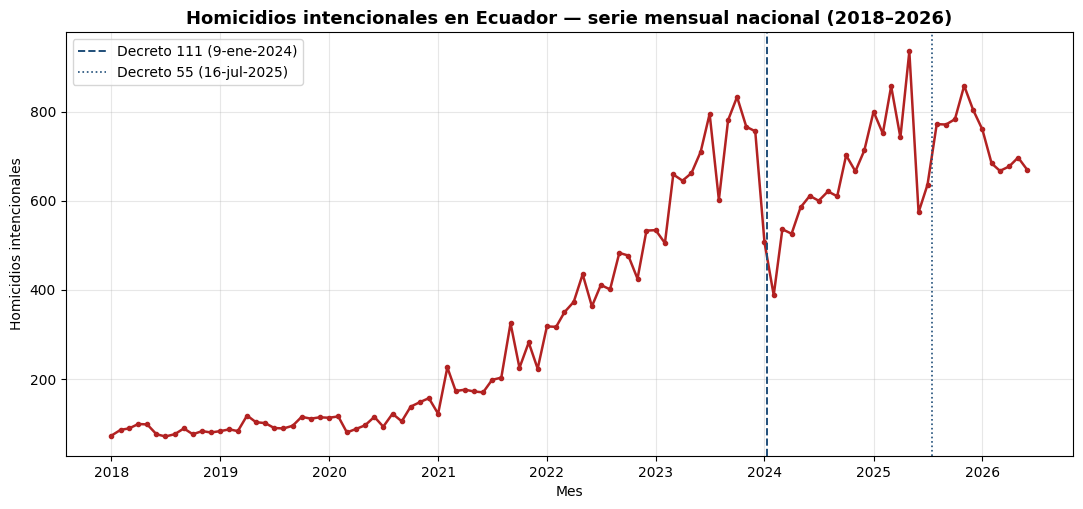

In [11]:
"""6. Figura: serie mensual nacional de homicidios intencionales 2018–2026."""

import matplotlib.pyplot as plt

# Serie mensual 2018–2025 (del histórico) + 2026.
serie_mensual = (
    df_hom[df_hom["anio"] >= config.ANIO_INICIO]
    .groupby(["anio", "mes"])
    .size()
)
serie_mensual = serie_mensual.add(
    df_hom26.groupby(["anio", "mes"]).size(), fill_value=0
)
serie_mensual = serie_mensual.sort_index()

fechas = pd.to_datetime(
    [f"{anio:04d}-{mes:02d}-01" for anio, mes in serie_mensual.index]
)
valores = serie_mensual.values

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(fechas, valores, color="#b22222", linewidth=1.8, marker="o", markersize=3)
ax.axvline(pd.Timestamp("2024-01-09"), color="#1f4e79", linestyle="--", linewidth=1.4,
           label="Decreto 111 (9-ene-2024)")
ax.axvline(pd.Timestamp("2025-07-16"), color="#1f4e79", linestyle=":", linewidth=1.2,
           label="Decreto 55 (16-jul-2025)")
ax.set_title("Homicidios intencionales en Ecuador — serie mensual nacional (2018–2026)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Homicidios intencionales")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

# Guardar en reports/figures. La ruta relativa del repo (RAIZ/reports/figures)
# es la misma ruta absoluta de entrega del proyecto (DELIVERY/.../reports/figures),
# por lo que una sola escritura satisface ambos contratos.
carpeta_figuras = RAIZ / "reports" / "figures"
carpeta_figuras.mkdir(parents=True, exist_ok=True)
ruta_figura = carpeta_figuras / "fig_homicidios_nacional.png"
fig.savefig(ruta_figura, dpi=150, bbox_inches="tight")

print("Figura guardada en:", ruta_figura.resolve())
print("Meses en la serie:", len(serie_mensual), "| Pico mensual:", int(valores.max()),
      "| Mínimo mensual:", int(valores.min()))
try:
    plt.show()
except Exception:
    pass  # entorno sin display: la figura ya quedó guardada en disco


# ## 7. Hallazgos preliminares del data understanding
#
# 1. **Escalada verificada:** 996 homicidios en 2018 → 9 283 en 2025 (×9,3); 4 154 en solo el primer semestre de 2026. El salto se acelera a partir de 2021 y se dispara en 2023.
# 2. **Concentración extrema:** Guayas concentra el **44,2 %** del total 2018–2025 (15 712 de 35 533). Las cinco primeras provincias explican ~85 % del total → motiva la prueba de robustez sin Guayas (notebook 05).
# 3. **Composición del registro:** 2018–2025 se compone de ASESINATO (31 117), HOMICIDIO (2 951), FEMICIDIO (813) y SICARIATO (243) en el panel; la categoría "homicidio intencional" oficial = suma de todas.
# 4. **Calidad de datos:** 187 duplicados en el histórico (0,47 %) y 32 en 2026; 295 nulos solo en `edad`; `codigo_provincia` es entero → normalizar con `zfill(2)`. Galápagos no aparece en 2026 (0 casos o registro pendiente).
# 5. **Mercado laboral:** las tasas provinciales 2024-II calculadas con microdatos coinciden con el boletín oficial (nacional 3,48 % / 20,97 % / 35,01 %). Los tabulados XLSX no tienen provincia → los microdatos son la única vía provincial.
# 6. **Discrepancia honesta (contraste externo):** el OECO reporta 4 619 homicidios para el S1-2025; el dataset oficial suma 4 659 (Δ ≈ 0,9 %, atribuible a cortes de fecha y variaciones del registro, reconocidas en el propio metadato).
#
# A continuación guardamos **versiones crudas normalizadas** (solo llaves DPA y variables necesarias) en `data/processed/`, listas para la fase de preparación (notebook 03).


In [12]:
"""7. Guardado de versiones crudas normalizadas en data/processed/."""

import pandas as pd

config.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# --- Homicidios: incidentes 2018–2026 con llave DPA de 2 dígitos ---
df_hom_2018 = df_hom[df_hom["anio"] >= config.ANIO_INICIO].copy()
df_hom_2018["dpa_provincia"] = df_hom_2018["codigo_provincia"].astype("Int64").astype(str).str.zfill(2)
df_hom_2026 = df_hom26.copy()
df_hom_2026["dpa_provincia"] = df_hom_2026["codigo_provincia"].astype("Int64").astype(str).str.zfill(2)

homicidios_norm = pd.concat(
    [df_hom_2018, df_hom_2026], ignore_index=True
)[["anio", "mes", "fecha_infraccion", "dpa_provincia", "provincia",
   "tipo_muerte", "sexo", "edad", "canton"]]

ruta_hom = config.DATA_PROCESSED / "homicidios_incidentes_2018_2026.csv"
homicidios_norm.to_csv(ruta_hom, index=False, encoding="utf-8-sig")
print("Guardado:", ruta_hom.name, "| filas:", len(homicidios_norm))

# --- Tasas ENEMDU 2024-II por provincia (ya calculadas en la sección 4b) ---
ruta_tasas = config.DATA_PROCESSED / "tasas_enemdu_2024_II_provincial.csv"
tabla_tasas.to_csv(ruta_tasas, index=False, encoding="utf-8-sig")
print("Guardado:", ruta_tasas.name, "| filas:", len(tabla_tasas))

# --- Población: subconjunto del panel 2018–2026 ---
poblacion_panel = df_pob[df_pob["anio"].between(config.ANIO_INICIO, config.ANIO_FIN)].copy()
poblacion_panel["dpa_provincia"] = poblacion_panel["dpa_provin"].astype(int).astype(str).str.zfill(2)
ruta_pob = config.DATA_PROCESSED / "poblacion_provincial_2018_2026.csv"
poblacion_panel.to_csv(ruta_pob, index=False, encoding="utf-8-sig")
print("Guardado:", ruta_pob.name, "| filas:", len(poblacion_panel))

print("\nContenido de data/processed/:")
for archivo in sorted(config.DATA_PROCESSED.glob("*.csv")):
    print(" -", archivo.name)


Guardado: homicidios_incidentes_2018_2026.csv | filas: 39687
Guardado: tasas_enemdu_2024_II_provincial.csv | filas: 24
Guardado: poblacion_provincial_2018_2026.csv | filas: 216

Contenido de data/processed/:
 - homicidios_incidentes_2018_2026.csv
 - panel_homicidios.csv
 - panel_provincia_trimestre.csv
 - poblacion_provincial_2018_2026.csv
 - tasas_enemdu_2024_II_provincial.csv
 - tasas_enemdu_provincial.csv
 - tasas_enemdu_provinciales_referencia.csv


# ## 8. Cierre de la fase
#
# Con esto queda **verificado y perfilado** el 100 % de las fuentes que alimentarán el panel:
#
# | Fuente | Archivo | Registros | Llave |
# |---|---|---|---|
# | Homicidios 2018–2025 | `2014_2025.xlsx` | 35 533 (panel) | `dpa_provincia` (zfill 2) |
# | Homicidios 2026 | `2026_enero_junio.xlsx` | 4 154 | `dpa_provincia` |
# | Población | `poblacion_provincial_1990_2035_tidy.csv` | 1 104 (24 × 46 años) | `dpa_provin` |
# | Geografía | `ORGANIZACION_TERRITORIAL_PROVINCIAL.shp` | 24 provincias | `DPA_PROVIN` |
# | ENEMDU 2024-II | `enemdu_persona_2024_II_trimestre.sav` | 85 708 personas | `ciudad` → DPA |
# | Tabulados | `202605_Tabulados_Mercado_Laboral_EXCEL.xlsx` | nacional (sin provincia) | — |
#
# Siguiente paso: **Notebook 03 — Preparación de datos** (agregación provincia-trimestre, panel con tasas por 100 000 y normalización completa con `src/data_prep.py`).